# 1. Introducción y Contexto del Problema

## 1.1 Problema de Negocio

En una empresa de comercio electrónico, comprender el comportamiento de los clientes es fundamental para optimizar las estrategias de marketing y mejorar la experiencia del usuario. La **segmentación de clientes** permite identificar grupos específicos de usuarios con comportamientos similares, facilitando la personalización de campañas y la toma de decisiones estratégicas.

## 1.2 Objetivo

Segmentar a los visitantes del sitio web en grupos distintos basándose en su comportamiento y características, para diseñar campañas de marketing más efectivas y mejorar la retención.

## 1.3 Descripción del Dataset

Los datos provienen de Google Analytics y contienen **13 variables** sobre la actividad de los visitantes. Un hallazgo estructural importante: el dataset viene **pre-agregado a nivel visitante** — cada fila es un visitante único, no una sesión individual. Esto tiene implicaciones directas sobre cómo interpretar variables como `sessionId` (que es realmente un conteo de sesiones) y `weekend_prop` (proporción, no un indicador binario).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, chi2_contingency, shapiro
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Cargar datos
df = pd.read_csv('../data/raw/data_customers.csv')
print(f"Dataset: {df.shape[0]:,} visitantes × {df.shape[1]} variables")
df.head()


Dataset: 9,996 visitantes × 13 variables


,fullVisitorId,channelGrouping,weekend_prop,hour,sessionId,device.browser,device.deviceCategory,device.isMobile,device.operatingSystem,totals.hits,totals.pageviews,bounce_prop,trafficSource.medium
0,213131142648941,Direct,0.000000,22.0,1,Chrome,desktop,0.0,Macintosh,14.0,13.0,0.0,(none)
1,435324061339869,Referral,0.666667,21.0,3,Chrome,desktop,0.0,Macintosh,14.0,11.0,0.0,referral
2,562678147042735,Organic Search,0.000000,14.0,2,Chrome,desktop,0.0,Macintosh,12.5,10.5,0.0,organic
3,585708896049892,Referral,0.000000,20.0,1,Chrome,desktop,0.0,Linux,22.0,20.0,0.0,referral
4,670722016498267,Referral,0.000000,17.0,2,Chrome,desktop,0.0,Linux,9.5,9.5,0.0,referral


## 1.4 Hallazgo Estructural: Dataset Pre-agregado

`sessionId` no es un identificador de sesión sino un **conteo de sesiones por visitante**. Las variables `weekend_prop` y `bounce_prop` son **proporciones entre sesiones**, no indicadores binarios. Esto significa que cada fila ya resume el comportamiento completo de un visitante a lo largo de todas sus visitas.


In [2]:
# Verificar: sessionId es conteo de sesiones
print("sessionId - Estadísticas:")
print(f"  Min: {df['sessionId'].min()}, Max: {df['sessionId'].max()}")
print(f"  Media: {df['sessionId'].mean():.2f}")
print(f"  Visitantes con >1 sesión: {(df['sessionId'] > 1).sum()} ({(df['sessionId'] > 1).mean()*100:.1f}%)")

# Renombramos para claridad
df = df.rename(columns={'sessionId': 'n_sessions'})
print(f"\nRenombrado: sessionId → n_sessions")

# Verificar proporciones
print(f"\nweekend_prop en [0,1]: {(df['weekend_prop'].between(0,1)).all()}")
print(f"bounce_prop en [0,1]: {(df['bounce_prop'].between(0,1)).all()}")

# Visitantes multi-dispositivo (isMobile decimal)
multi_device = df[df['device.isMobile'].apply(lambda x: x != int(x))]
print(f"\nVisitantes multi-dispositivo (isMobile decimal): {len(multi_device)}")
if len(multi_device) > 0:
    print(multi_device[['fullVisitorId', 'device.isMobile', 'device.deviceCategory']].head())


sessionId - Estadísticas:
  Min: 1, Max: 278
  Media: 3.61
  Visitantes con >1 sesión: 6866 (68.7%)

Renombrado: sessionId → n_sessions

weekend_prop en [0,1]: True
bounce_prop en [0,1]: True

Visitantes multi-dispositivo (isMobile decimal): 4
            fullVisitorId  device.isMobile device.deviceCategory
1013   455718321769006834         0.500000               desktop
3968  3207713058277296455         0.666667                mobile
7701  7376750587981554489         0.833333                mobile
9708  9669933764937008223         0.307692                mobile


# 2. Análisis Exploratorio de Datos

## 2.1 Diccionario de Datos y Tipología


In [3]:
# Diccionario de datos completo
dict_data = []
for col in df.columns:
    dict_data.append({
        'Variable': col,
        'Tipo': str(df[col].dtype),
        'Cardinalidad': df[col].nunique(),
        '% Único': round(df[col].nunique() / len(df) * 100, 2),
        'Nulos': df[col].isnull().sum(),
        'Ejemplo': df[col].iloc[0]
    })
pd.DataFrame(dict_data).set_index('Variable')


,Tipo,Cardinalidad,% Único,Nulos,Ejemplo
Variable,,,,,
fullVisitorId,uint64,9996,100.00,0,213131142648941
channelGrouping,object,8,0.08,0,Direct
weekend_prop,float64,104,1.04,0,0.0
hour,float64,47,0.47,0,22.0
n_sessions,int64,54,0.54,0,1
device.browser,object,9,0.09,0,Chrome
device.deviceCategory,object,3,0.03,0,desktop
device.isMobile,float64,6,0.06,0,0.0
device.operatingSystem,object,7,0.07,0,Macintosh


## 2.2 Calidad de Datos


In [4]:
# Nulos
print("=== NULOS POR COLUMNA ===")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

# Duplicados
dupes = df.duplicated(subset=['fullVisitorId']).sum()
print(f"\n=== DUPLICADOS ===")
print(f"Visitantes duplicados: {dupes}")

# Coherencia lógica
print("\n=== VERIFICACIONES DE COHERENCIA ===")
print(f"pageviews ≤ hits: {(df['totals.pageviews'] <= df['totals.hits']).all()}")
print(f"weekend_prop en [0,1]: {df['weekend_prop'].between(0,1).all()}")
print(f"bounce_prop en [0,1]: {df['bounce_prop'].between(0,1).all()}")
print(f"hour en [0,23]: {df['hour'].between(0,23).all()}")
print(f"n_sessions ≥ 1: {(df['n_sessions'] >= 1).all()}")


=== NULOS POR COLUMNA ===
fullVisitorId             0
channelGrouping           0
weekend_prop              0
hour                      0
n_sessions                0
device.browser            0
device.deviceCategory     0
device.isMobile           0
device.operatingSystem    0
totals.hits               0
totals.pageviews          0
bounce_prop               0
trafficSource.medium      0
dtype: int64

Total nulos: 0

=== DUPLICADOS ===
Visitantes duplicados: 0

=== VERIFICACIONES DE COHERENCIA ===
pageviews ≤ hits: True
weekend_prop en [0,1]: True
bounce_prop en [0,1]: True
hour en [0,23]: True
n_sessions ≥ 1: True


## 2.3 Análisis Univariado Numérico


In [5]:
num_cols = ['n_sessions', 'totals.hits', 'totals.pageviews', 'bounce_prop', 'weekend_prop', 'hour']

# Estadísticos completos
stats_df = df[num_cols].describe().T
stats_df['skew'] = df[num_cols].skew()
stats_df['kurtosis'] = df[num_cols].kurtosis()
stats_df['iqr'] = stats_df['75%'] - stats_df['25%']
print("=== ESTADÍSTICOS DESCRIPTIVOS ===")
display(stats_df.round(3))

# Hallazgo: variables con alta asimetría
print("\n=== VARIABLES CON ALTA ASIMETRÍA ===")
high_skew = stats_df[stats_df['skew'].abs() > 2]
for idx, row in high_skew.iterrows():
    print(f"  {idx}: skew={row['skew']:.2f}, kurtosis={row['kurtosis']:.2f}")
print("\nImplicación: tests paramétricos descartados, necesidad de transformación log.")


=== ESTADÍSTICOS DESCRIPTIVOS ===


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,iqr
n_sessions,9996.0,3.606,6.074,1.0,1.0,2.0,4.000,278.000,19.667,657.098,3.000
totals.hits,9996.0,22.178,21.917,1.0,9.0,17.0,28.000,500.000,5.128,68.381,19.000
totals.pageviews,9996.0,17.530,16.259,1.0,8.0,14.0,22.500,466.000,6.652,127.116,14.500
bounce_prop,9996.0,0.083,0.162,0.0,0.0,0.0,0.083,0.925,1.973,3.097,0.083
weekend_prop,9996.0,0.147,0.296,0.0,0.0,0.0,0.126,1.000,2.031,2.852,0.126
hour,9996.0,14.449,6.261,0.0,11.0,16.5,19.000,23.000,-0.903,-0.318,8.000



=== VARIABLES CON ALTA ASIMETRÍA ===
  n_sessions: skew=19.67, kurtosis=657.10
  totals.hits: skew=5.13, kurtosis=68.38
  totals.pageviews: skew=6.65, kurtosis=127.12
  weekend_prop: skew=2.03, kurtosis=2.85

Implicación: tests paramétricos descartados, necesidad de transformación log.


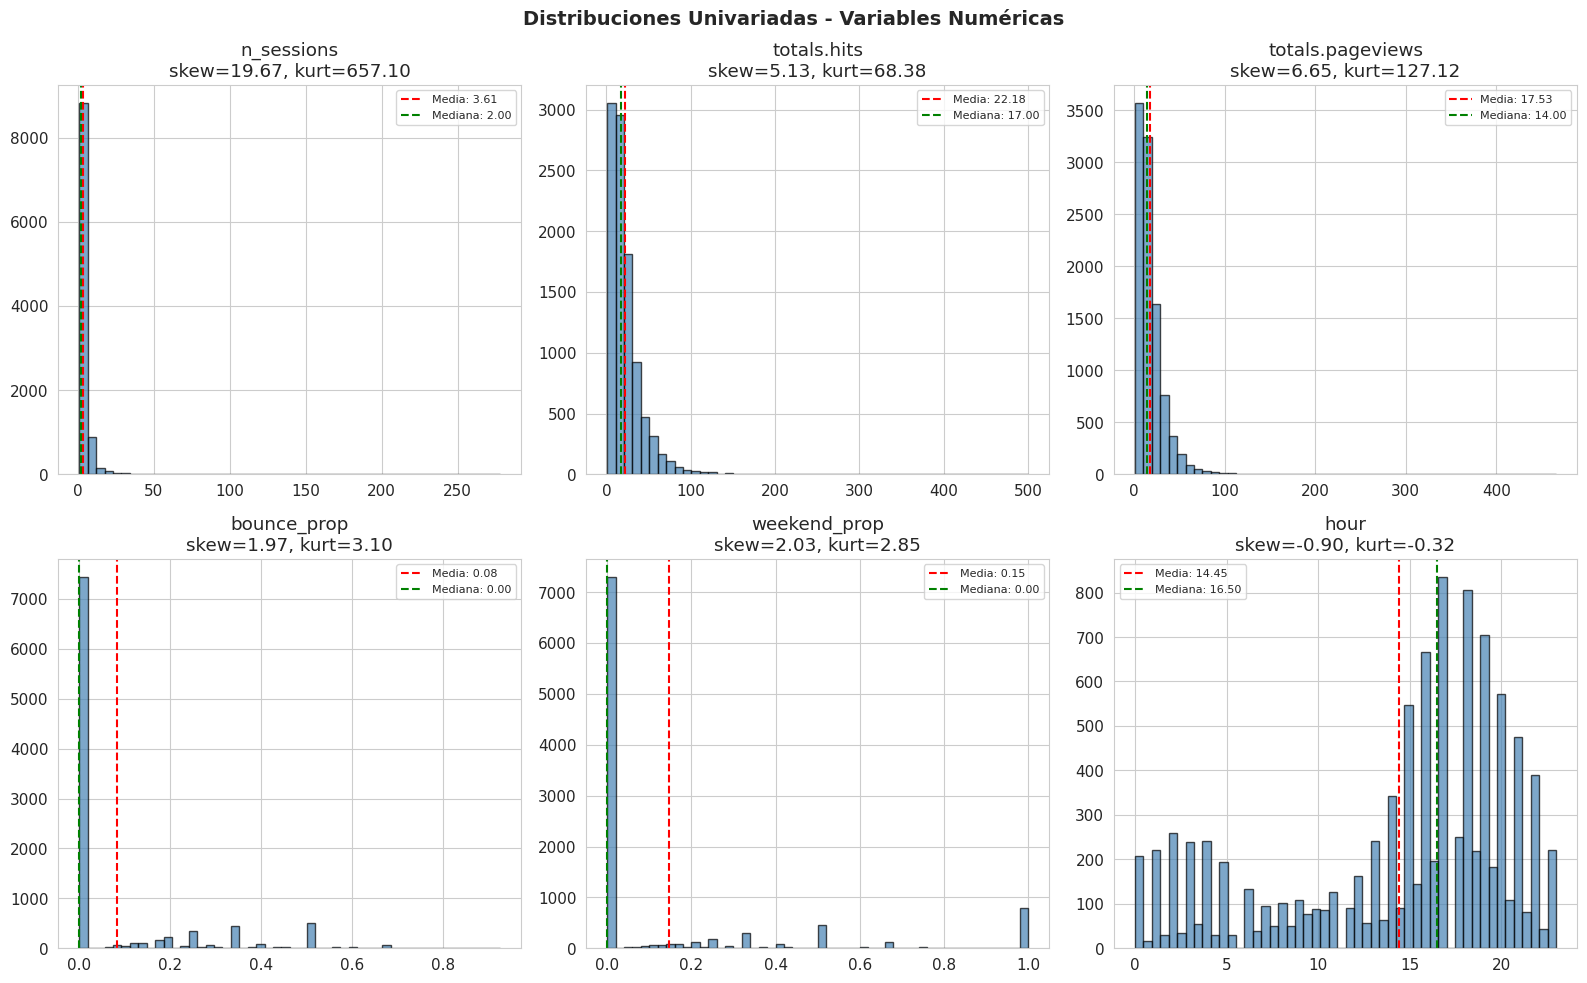

In [6]:
# Distribuciones
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(num_cols):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'Mediana: {df[col].median():.2f}')
    ax.set_title(f'{col}\nskew={df[col].skew():.2f}, kurt={df[col].kurtosis():.2f}')
    ax.legend(fontsize=8)
plt.suptitle('Distribuciones Univariadas - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/univariado_numerico.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.4 Detección de Outliers Univariados


In [7]:
# Regla IQR
print("=== OUTLIERS POR REGLA IQR (Q3 + 1.5·IQR) ===\n")
outlier_summary = []
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    n_out = ((df[col] > upper) | (df[col] < lower)).sum()
    pct = n_out / len(df) * 100
    outlier_summary.append({'Variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'Límite inferior': lower, 'Límite superior': upper,
                           'N outliers': n_out, '% outliers': round(pct, 2)})
display(pd.DataFrame(outlier_summary).set_index('Variable'))
print("\nDecisión: NO eliminar outliers. Transformar con clip P99 + log1p en preprocesamiento.")


=== OUTLIERS POR REGLA IQR (Q3 + 1.5·IQR) ===



,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers,% outliers
Variable,,,,,,,
n_sessions,1.0,4.000000,3.000000,-3.500000,8.500000,689,6.89
totals.hits,9.0,28.000000,19.000000,-19.500000,56.500000,594,5.94
totals.pageviews,8.0,22.500000,14.500000,-13.750000,44.250000,501,5.01
bounce_prop,0.0,0.083333,0.083333,-0.125000,0.208333,1792,17.93
weekend_prop,0.0,0.126359,0.126359,-0.189538,0.315897,1905,19.06
hour,11.0,19.000000,8.000000,-1.000000,31.000000,0,0.00



Decisión: NO eliminar outliers. Transformar con clip P99 + log1p en preprocesamiento.


## 2.5 Análisis Univariado Categórico


In [8]:
cat_cols = ['channelGrouping', 'device.browser', 'device.deviceCategory', 'device.operatingSystem', 'trafficSource.medium']

print("=== ANÁLISIS CATEGÓRICO ===\n")
for col in cat_cols:
    vc = df[col].value_counts(normalize=True)
    gini = 1 - (vc**2).sum()
    print(f"--- {col} ---")
    print(f"  Cardinalidad: {df[col].nunique()}")
    print(f"  Top: {vc.index[0]} ({vc.iloc[0]*100:.1f}%)")
    print(f"  Gini impureza: {gini:.3f}")
    # Categorías raras
    rare = vc[vc < 0.01]
    if len(rare) > 0:
        print(f"  Categorías raras (<1%): {list(rare.index)}")
    print()


=== ANÁLISIS CATEGÓRICO ===

--- channelGrouping ---
  Cardinalidad: 8
  Top: Referral (42.9%)
  Gini impureza: 0.675
  Categorías raras (<1%): ['Social', 'Affiliates', '(Other)']

--- device.browser ---
  Cardinalidad: 9
  Top: Chrome (89.4%)
  Gini impureza: 0.195
  Categorías raras (<1%): ['Internet Explorer', 'Edge', 'Safari (in-app)', 'Android Webview', 'Opera', 'Amazon Silk']

--- device.deviceCategory ---
  Cardinalidad: 3
  Top: desktop (90.3%)
  Gini impureza: 0.178

--- device.operatingSystem ---
  Cardinalidad: 7
  Top: Macintosh (55.5%)
  Gini impureza: 0.636
  Categorías raras (<1%): ['Windows Phone']

--- trafficSource.medium ---
  Cardinalidad: 7
  Top: referral (43.7%)
  Gini impureza: 0.673
  Categorías raras (<1%): ['affiliate', '(not set)']



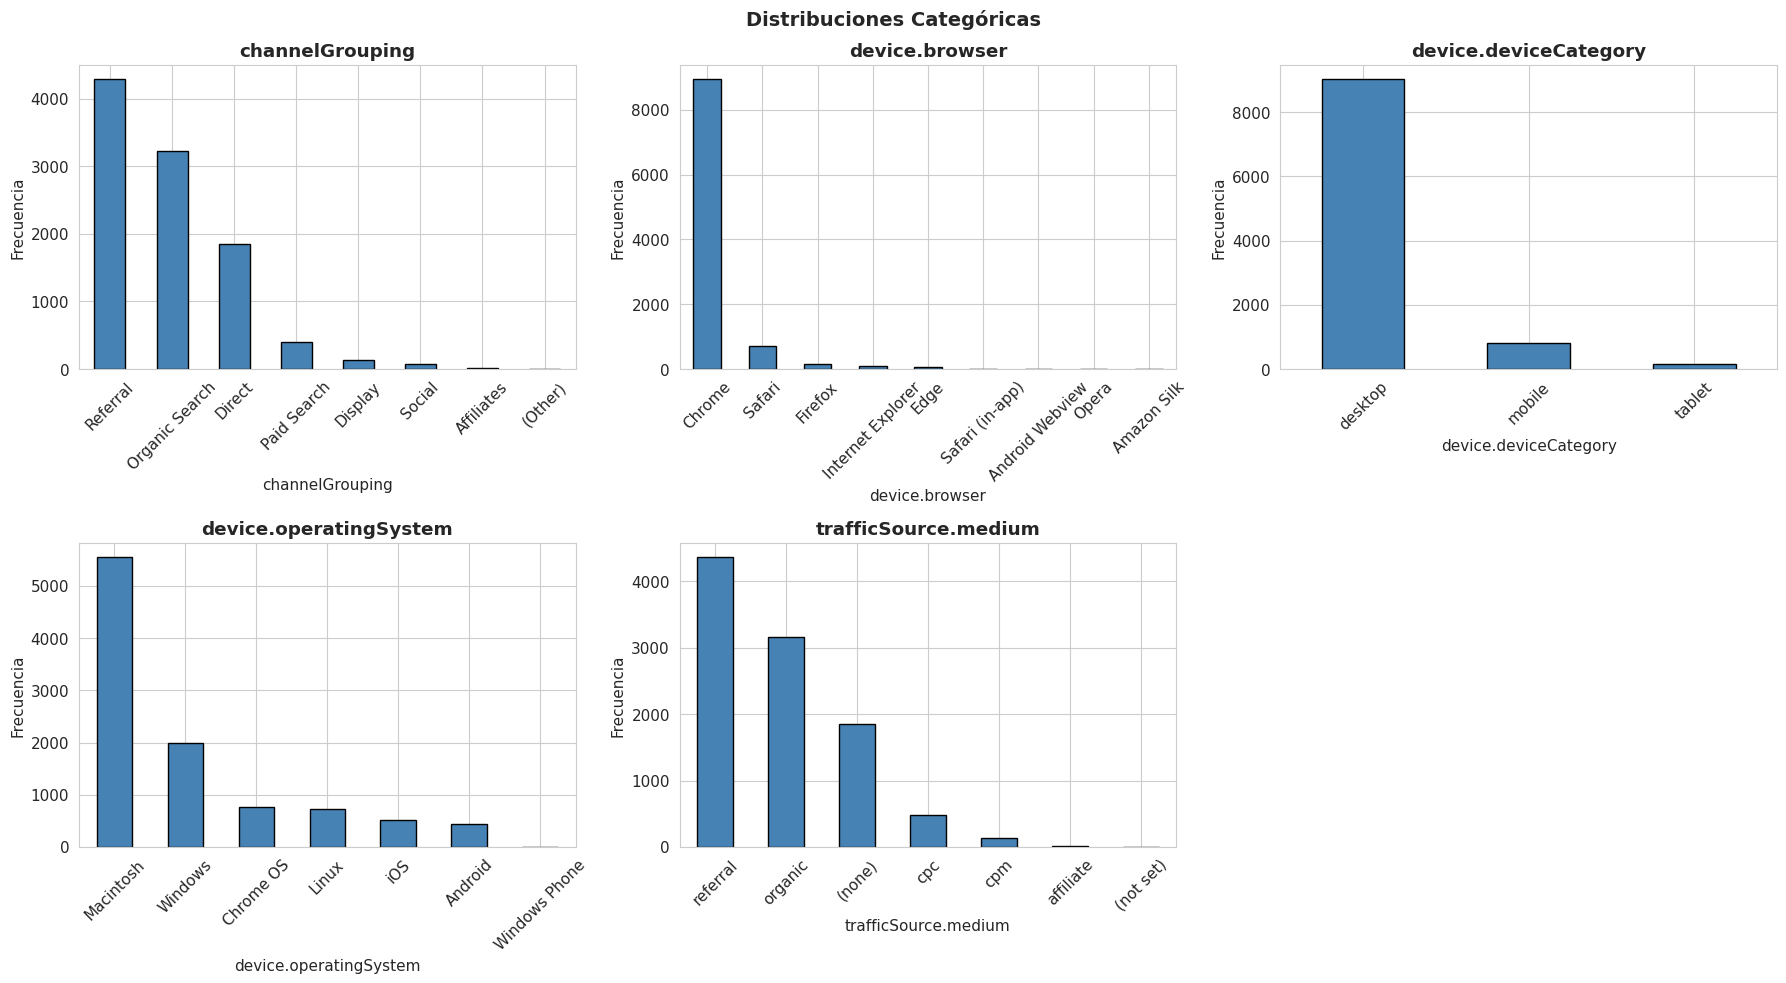

In [9]:
# Visualización categórica
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(cat_cols):
    ax = axes[i//3, i%3]
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)
axes[1, 2].axis('off')
plt.suptitle('Distribuciones Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/univariado_categorico.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.6 Correlaciones y Multicolinealidad


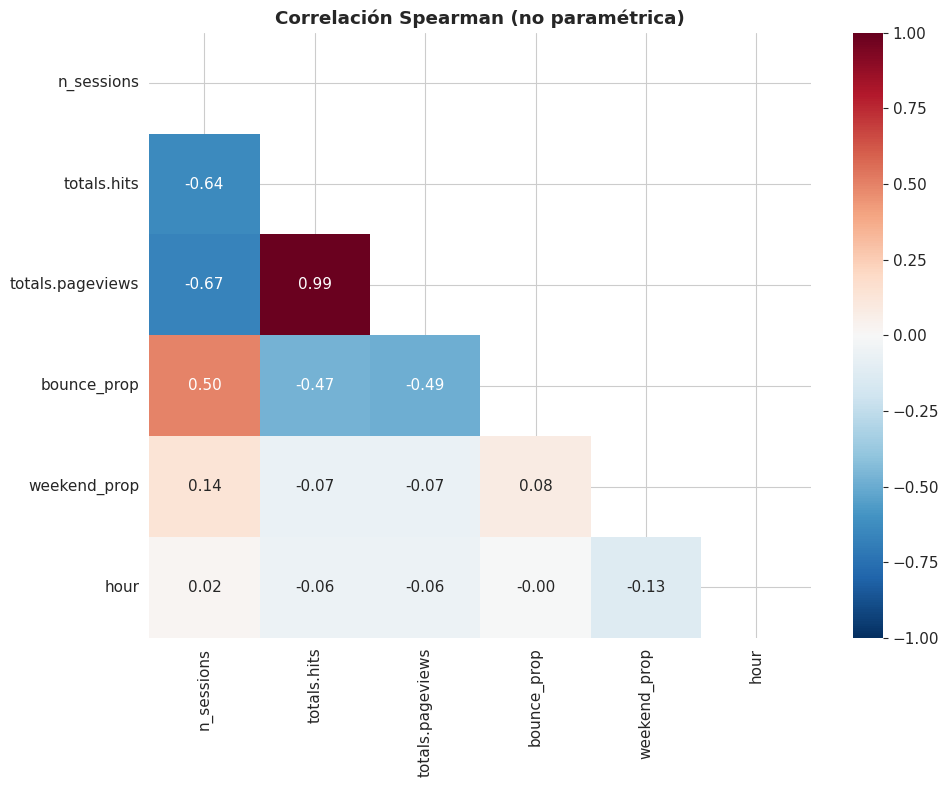


=== PARES CON |ρ| > 0.5 ===
  n_sessions ↔ totals.hits: ρ = -0.637
  n_sessions ↔ totals.pageviews: ρ = -0.670
  totals.hits ↔ totals.pageviews: ρ = 0.986


In [10]:
# Correlación Spearman (preferida: datos no normales)
spearman_corr = df[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlación Spearman (no paramétrica)', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/correlacion_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares con alta correlación
print("\n=== PARES CON |ρ| > 0.5 ===")
for i in range(len(spearman_corr)):
    for j in range(i+1, len(spearman_corr)):
        r = spearman_corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {spearman_corr.index[i]} ↔ {spearman_corr.columns[j]}: ρ = {r:.3f}")


In [11]:
# VIF - Multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[num_cols].dropna()
vif_data = pd.DataFrame({
    'Variable': num_cols,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(len(num_cols))]
}).sort_values('VIF', ascending=False)
display(vif_data)

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\nVariables con VIF > 10 (multicolinealidad alta):")
    for _, r in high_vif.iterrows():
        print(f"  {r['Variable']}: VIF = {r['VIF']:.1f}")


,Variable,VIF
2,totals.pageviews,58.837295
1,totals.hits,56.014240
5,hour,2.432045
0,n_sessions,1.400929
3,bounce_prop,1.337746
4,weekend_prop,1.206473



Variables con VIF > 10 (multicolinealidad alta):
  totals.pageviews: VIF = 58.8
  totals.hits: VIF = 56.0


## 2.7 Análisis Bivariado: Categórica vs Numérica

Para cada variable categórica, calculamos el **effect size η² (Kruskal-Wallis)** contra cada numérica. Esto nos dice qué tan bien separa una categórica sola a los visitantes — y justifica por qué necesitamos clustering multivariado.


In [12]:
# Effect size η² por categórica vs numérica
print("=== EFFECT SIZE η² (Kruskal-Wallis) ===\n")
eta_results = []
for cat in cat_cols:
    for num in num_cols:
        groups = [g[num].dropna().values for _, g in df.groupby(cat)]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) < 2:
            continue
        H, p = kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        eta2 = (H - k + 1) / (n - k)
        eta_results.append({'Categórica': cat, 'Numérica': num, 'η²': round(eta2, 4), 'p': p})

eta_df = pd.DataFrame(eta_results).pivot(index='Categórica', columns='Numérica', values='η²')
display(eta_df.style.background_gradient(cmap='YlOrRd'))
print("\nHallazgo: ninguna categórica separa fuertemente por sí sola.")
print("Implicación: se justifica clustering MULTIVARIADO en lugar de reglas simples.")


=== EFFECT SIZE η² (Kruskal-Wallis) ===



Numérica,bounce_prop,hour,n_sessions,totals.hits,totals.pageviews,weekend_prop
Categórica,,,,,,
channelGrouping,-0.000300,0.013500,0.021600,0.006400,0.008100,0.015100
device.browser,0.003000,0.007900,0.009700,0.000800,0.001000,0.011000
device.deviceCategory,0.018000,0.011200,0.001000,0.004200,0.003300,0.015200
device.operatingSystem,0.019700,0.019200,0.011200,0.008800,0.009400,0.024300
trafficSource.medium,0.000400,0.013600,0.020200,0.006500,0.008300,0.015200



Hallazgo: ninguna categórica separa fuertemente por sí sola.
Implicación: se justifica clustering MULTIVARIADO en lugar de reglas simples.


## 2.8 Análisis Bivariado: Categórica vs Categórica


In [13]:
# Cramer's V entre categóricas
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

print("=== CRAMER'S V ENTRE CATEGÓRICAS ===\n")
v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if i <= j:
            v = cramers_v(df[c1], df[c2]) if i != j else 1.0
            v_matrix.loc[c1, c2] = v
            v_matrix.loc[c2, c1] = v

display(v_matrix.round(3))

# Hallazgos críticos
print("\nHallazgos:")
print("  channelGrouping ↔ trafficSource.medium: V ≈ 0.98 → REDUNDANCIA PERFECTA")
print("  deviceCategory ↔ operatingSystem: V alta → asociación fuerte")
print("\nDecisión: eliminar trafficSource.medium en preprocesamiento.")


=== CRAMER'S V ENTRE CATEGÓRICAS ===



,channelGrouping,device.browser,device.deviceCategory,device.operatingSystem,trafficSource.medium
channelGrouping,1.000,0.131,0.206,0.182,0.983
device.browser,0.131,1.000,0.344,0.306,0.131
device.deviceCategory,0.206,0.344,1.000,0.708,0.206
device.operatingSystem,0.182,0.306,0.708,1.000,0.179
trafficSource.medium,0.983,0.131,0.206,0.179,1.000



Hallazgos:
  channelGrouping ↔ trafficSource.medium: V ≈ 0.98 → REDUNDANCIA PERFECTA
  deviceCategory ↔ operatingSystem: V alta → asociación fuerte

Decisión: eliminar trafficSource.medium en preprocesamiento.


## 2.9 Outliers Multivariados con Isolation Forest


In [14]:
from sklearn.ensemble import IsolationForest

X_iso = df[num_cols].copy()
iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
df['is_outlier'] = iso.fit_predict(X_iso)
df['is_outlier'] = df['is_outlier'].map({1: 'Normal', -1: 'Outlier'})

n_outliers = (df['is_outlier'] == 'Outlier').sum()
print(f"Outliers multivariados detectados: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")

# Perfil outliers vs normales
print("\n=== PERFIL OUTLIERS vs NORMALES ===")
comparison = df.groupby('is_outlier')[num_cols].mean().T
comparison['ratio'] = comparison['Outlier'] / comparison['Normal']
display(comparison.round(3))

# Variable más discriminante
print(f"\nSeparador más fuerte: la variable con mayor ratio outlier/normal")
print(f"Anticipación: estos outliers probablemente formarán su propio cluster.")

# Limpiar columna auxiliar
df = df.drop('is_outlier', axis=1)


Outliers multivariados detectados: 500 (5.0%)

=== PERFIL OUTLIERS vs NORMALES ===


is_outlier,Normal,Outlier,ratio
n_sessions,3.322,9.004,2.710
totals.hits,20.321,57.440,2.827
totals.pageviews,16.237,42.092,2.592
bounce_prop,0.075,0.224,2.979
weekend_prop,0.130,0.476,3.668
hour,14.639,10.849,0.741



Separador más fuerte: la variable con mayor ratio outlier/normal
Anticipación: estos outliers probablemente formarán su propio cluster.


## 2.10 Síntesis del EDA

### Hallazgos principales:

1. **Dataset limpio**: 0 nulos, 0 duplicados, coherencia lógica verificada
2. **Distribuciones sesgadas**: n_sessions, totals.hits, totals.pageviews con skew > 2 → requieren transformación log
3. **Multicolinealidad**: hits y pageviews altamente correlacionados (VIF > 10), pero se conservan por su valor informativo en clustering
4. **Redundancia categórica**: channelGrouping ≈ trafficSource.medium (V=0.98) → eliminar una
5. **Dominancia de categorías**: Chrome 89%, Desktop 90%, Mac 56% → necesidad de agrupar raras
6. **Ninguna categórica separa sola**: η² bajos → justifica clustering multivariado
7. **Outliers multivariados** (5%): engagement 5x superior, anticipan un cluster de power users
8. **Correlación negativa** n_sessions vs totals.hits: coexisten visitantes-research (pocas sesiones, muchos hits) vs visitantes-chequeo (muchas sesiones, pocos hits)

Estas observaciones guían directamente el preprocesamiento del siguiente notebook.
